<a href="https://colab.research.google.com/github/BenCoop16/IS-477/blob/main/is477_proj_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Bitcoin Reddit Sentiment Project**

###Installs and Imports

In [66]:
!pip install vaderSentiment


In [67]:
import requests
import pandas as pd
import datetime
import time
import yfinance as yf
from google.colab import files
from datetime import datetime, timedelta
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy.stats import linregress

##**Data Imports**

###Reddit Sentiment Data via Arctic Shift

In [68]:
all_posts = []

start_date = datetime(2024, 1, 1)
end_date = datetime(2026, 1, 1)
posts_per_week = 30

current = start_date
while current < end_date:
    next_week = current + timedelta(weeks=1)

    params = {
        "subreddit": "Bitcoin",
        "after": current.strftime("%Y-%m-%d"),
        "before": next_week.strftime("%Y-%m-%d"),
        "limit": posts_per_week,
        "sort": "asc"
    }

    response = requests.get("https://arctic-shift.photon-reddit.com/api/posts/search", params=params)
    batch = response.json().get('data') or []

    if batch:
        all_posts.extend(batch)

    print(f"Week of {current.date()}: {len(batch)} posts, total: {len(all_posts)}")
    current = next_week
    time.sleep(0.5)

Week of 2024-01-01: 30 posts, total: 30
Week of 2024-01-08: 30 posts, total: 60
Week of 2024-01-15: 30 posts, total: 90
Week of 2024-01-22: 30 posts, total: 120
Week of 2024-01-29: 30 posts, total: 150
Week of 2024-02-05: 30 posts, total: 180
Week of 2024-02-12: 30 posts, total: 210
Week of 2024-02-19: 30 posts, total: 240
Week of 2024-02-26: 30 posts, total: 270
Week of 2024-03-04: 30 posts, total: 300
Week of 2024-03-11: 30 posts, total: 330
Week of 2024-03-18: 30 posts, total: 360
Week of 2024-03-25: 30 posts, total: 390
Week of 2024-04-01: 30 posts, total: 420
Week of 2024-04-08: 30 posts, total: 450
Week of 2024-04-15: 30 posts, total: 480
Week of 2024-04-22: 30 posts, total: 510
Week of 2024-04-29: 30 posts, total: 540
Week of 2024-05-06: 30 posts, total: 570
Week of 2024-05-13: 30 posts, total: 600
Week of 2024-05-20: 30 posts, total: 630
Week of 2024-05-27: 30 posts, total: 660
Week of 2024-06-03: 30 posts, total: 690
Week of 2024-06-10: 30 posts, total: 720
Week of 2024-06-17:

In [69]:
df_bitcoin = pd.DataFrame(all_posts)[['id', 'title', 'selftext', 'score', 'upvote_ratio', 'num_comments', 'created_utc', 'subreddit']]
df_bitcoin['timestamp'] = pd.to_datetime(df_bitcoin['created_utc'], unit='s')
print(df_bitcoin.shape)

(3150, 9)


In [70]:
df_bitcoin.head()

,id,title,selftext,score,upvote_ratio,num_comments,created_utc,subreddit,timestamp
0,18vkhs0,Crypto Trading at Bybit! Sign up,[removed],1,1.0,0,1704067279,Bitcoin,2024-01-01 00:01:19
1,18vkiob,Anyone using AI legitimately to trade better? ...,Is anyone actually using AI to improve their c...,1,1.0,1,1704067351,Bitcoin,2024-01-01 00:02:31
2,18vkl5i,Crypto Trading at Bybit! Sign up at,[removed],1,1.0,1,1704067574,Bitcoin,2024-01-01 00:06:14
3,18vkngq,"ETF approval, demand change?",Has anyone looked at what the lagtime is betwe...,1,1.0,2,1704067808,Bitcoin,2024-01-01 00:10:08
4,18vkvy4,Mass Adoption after Mass Awareness - We are ge...,Visiting Flagstaff for New Years and found my ...,1,1.0,7,1704068581,Bitcoin,2024-01-01 00:23:01


###Bitcoin Price Data Upload

In [71]:
df_price = yf.download("BTC-USD", start="2024-01-01", end="2026-01-01", interval="1wk")

/tmp/ipykernel_33475/2037009529.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_price = yf.download("BTC-USD", start="2024-01-01", end="2026-01-01", interval="1wk")
[*********************100%***********************]  1 of 1 completed


In [72]:
df_price.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2024-01-01,43943.097656,45899.707031,40813.535156,42280.234375,202311773985
2024-01-08,41796.269531,48969.371094,41724.613281,43948.707031,259971819745
2024-01-15,41545.785156,43566.273438,40297.457031,41715.066406,139135824835
2024-01-22,42035.593750,42797.175781,38521.894531,41553.652344,155314602893
2024-01-29,42583.582031,43838.945312,41818.332031,42030.914062,135184187433


##**Data Cleaning Process**

In [73]:
print("Duplicates:", df_bitcoin.duplicated(subset='id').sum())
print("\nMissing values:")
print(df_bitcoin.isnull().sum())
print("\nRemoved posts (selftext is [removed]):", (df_bitcoin['selftext'] == '[removed]').sum())
print("Deleted posts (selftext is [deleted]):", (df_bitcoin['selftext'] == '[deleted]').sum())

Duplicates: 0

Missing values:
id              0
title           0
selftext        0
score           0
upvote_ratio    0
num_comments    0
created_utc     0
subreddit       0
timestamp       0
dtype: int64

Removed posts (selftext is [removed]): 820
Deleted posts (selftext is [deleted]): 12


In [74]:
df_bitcoin_clean = df_bitcoin[df_bitcoin['selftext'] != '[removed]']
df_bitcoin_clean = df_bitcoin_clean[df_bitcoin_clean['selftext'] != '[deleted]']
df_bitcoin_clean = df_bitcoin_clean.drop_duplicates(subset='id')
df_bitcoin_clean = df_bitcoin_clean.reset_index(drop=True)
print(df_bitcoin_clean.shape)

(2318, 9)


In [75]:
print("Duplicates:", df_price.duplicated().sum())
print("\nMissing values:")
print(df_price.isnull().sum())
print("\nPrice data types:")
print(df_price.dtypes)

Duplicates: 0

Missing values:
Price   Ticker 
Close   BTC-USD    0
High    BTC-USD    0
Low     BTC-USD    0
Open    BTC-USD    0
Volume  BTC-USD    0
dtype: int64

Price data types:
Price   Ticker 
Close   BTC-USD    float64
High    BTC-USD    float64
Low     BTC-USD    float64
Open    BTC-USD    float64
Volume  BTC-USD      int64
dtype: object


In [76]:
df_bitcoin_clean['timestamp'] = pd.to_datetime(df_bitcoin_clean['created_utc'], unit='s')
df_bitcoin_clean['week_start'] = (
    df_bitcoin_clean['timestamp']
    - pd.to_timedelta(df_bitcoin_clean['timestamp'].dt.dayofweek, unit='D')
).dt.normalize()

print('Reddit date range:')
print(df_bitcoin_clean['week_start'].min())
print(df_bitcoin_clean['week_start'].max())

Reddit date range:
2024-01-01 00:00:00
2025-12-29 00:00:00


In [77]:
df_price_clean = df_price.copy()
df_price_clean = df_price_clean.reset_index()

df_price_clean.columns = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in df_price_clean.columns]

df_price_clean.rename(columns={'price': 'date'}, inplace=True)
df_price_clean['date'] = pd.to_datetime(df_price_clean['date'])

#Normalizing to Monday so it lines up with week_start in the reddit data
df_price_clean['date'] = df_price_clean['date'] - pd.to_timedelta(df_price_clean['date'].dt.dayofweek, unit='D')

df_price_clean['price_change'] = df_price_clean['close'] - df_price_clean['open']
df_price_clean['price_pct_change'] = (df_price_clean['price_change'] / df_price_clean['open']) * 100

df_price_clean.to_csv('crypto_prices_raw.csv', index=False)
print(df_price_clean.shape)
print(df_price_clean.head())

(105, 8)
        date         close          high           low          open  \
0 2024-01-01  43943.097656  45899.707031  40813.535156  42280.234375   
1 2024-01-08  41796.269531  48969.371094  41724.613281  43948.707031   
2 2024-01-15  41545.785156  43566.273438  40297.457031  41715.066406   
3 2024-01-22  42035.593750  42797.175781  38521.894531  41553.652344   
4 2024-01-29  42583.582031  43838.945312  41818.332031  42030.914062   

         volume  price_change  price_pct_change  
0  202311773985   1662.863281          3.932957  
1  259971819745  -2152.437500         -4.897613  
2  139135824835   -169.281250         -0.405804  
3  155314602893    481.941406          1.159805  
4  135184187433    552.667969          1.314908  


In [78]:
print('Weekly price rows:', len(df_price_clean))

Weekly price rows: 105


In [79]:
df_bitcoin_clean.to_csv('reddit_bitcoin_clean.csv', index=False)
df_price_clean.to_csv('crypto_prices_clean.csv', index=False)
print("All files saved!")

All files saved!


##**Sentiment Analysis & Merging Datasets**

In [80]:
analyzer = SentimentIntensityAnalyzer()
df_bitcoin_clean['sentiment'] = df_bitcoin_clean['title'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
print(df_bitcoin_clean[['title', 'sentiment']].head(10))

                                               title  sentiment
0  Anyone using AI legitimately to trade better? ...     0.4404
1                       ETF approval, demand change?     0.3818
2  Mass Adoption after Mass Awareness - We are ge...     0.0000
3                                Bitcoin Yearly Lows    -0.2023
4                       Happy new year motherfuckers     0.5719
5  On the Lightning Network does the node operato...     0.3400
6                              This is where it ends     0.0000
7  Best place to store your Bitcoin from Coinbase...     0.8442
8  Yo why the Bitcoin fees so high right now is t...     0.0000
9                             Happy new year to all!     0.6114


In [81]:
def label_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df_bitcoin_clean['sentiment_label'] = df_bitcoin_clean['sentiment'].apply(label_sentiment)
print(df_bitcoin_clean['sentiment_label'].value_counts())

sentiment_label
neutral     1344
positive     621
negative     353
Name: count, dtype: int64


In [82]:
df_weekly_reddit = df_bitcoin_clean.groupby('week_start').agg(
    post_count=('id', 'count'),
    avg_score=('score', 'mean'),
    avg_upvote_ratio=('upvote_ratio', 'mean'),
    avg_comments=('num_comments', 'mean'),
    avg_sentiment=('sentiment', 'mean'),
    positive_ratio=('sentiment_label', lambda x: (x == 'positive').sum() / len(x)),
    negative_ratio=('sentiment_label', lambda x: (x == 'negative').sum() / len(x)),
).reset_index()
df_weekly_reddit.rename(columns={'week_start': 'date'}, inplace=True)

print(df_weekly_reddit.shape)
print(df_weekly_reddit.head())

(105, 8)
        date  post_count  avg_score  avg_upvote_ratio  avg_comments  \
0 2024-01-01          24   1.000000          0.958333     20.125000   
1 2024-01-08          24  38.625000          0.686250     26.458333   
2 2024-01-15          26  37.423077          0.616923     20.307692   
3 2024-01-22          24   6.625000          0.708750     14.458333   
4 2024-01-29          25   9.080000          0.649200     13.560000   

   avg_sentiment  positive_ratio  negative_ratio  
0       0.246454        0.500000        0.041667  
1       0.133475        0.333333        0.041667  
2       0.103381        0.346154        0.038462  
3       0.036675        0.291667        0.250000  
4       0.019376        0.320000        0.120000  


In [83]:
df_merged = pd.merge(df_weekly_reddit, df_price_clean, on='date', how='inner')
print(df_merged.shape)
print(df_merged.head())

(105, 15)
        date  post_count  avg_score  avg_upvote_ratio  avg_comments  \
0 2024-01-01          24   1.000000          0.958333     20.125000   
1 2024-01-08          24  38.625000          0.686250     26.458333   
2 2024-01-15          26  37.423077          0.616923     20.307692   
3 2024-01-22          24   6.625000          0.708750     14.458333   
4 2024-01-29          25   9.080000          0.649200     13.560000   

   avg_sentiment  positive_ratio  negative_ratio         close          high  \
0       0.246454        0.500000        0.041667  43943.097656  45899.707031   
1       0.133475        0.333333        0.041667  41796.269531  48969.371094   
2       0.103381        0.346154        0.038462  41545.785156  43566.273438   
3       0.036675        0.291667        0.250000  42035.593750  42797.175781   
4       0.019376        0.320000        0.120000  42583.582031  43838.945312   

            low          open        volume  price_change  price_pct_change  
0  4

##**Visualizations**

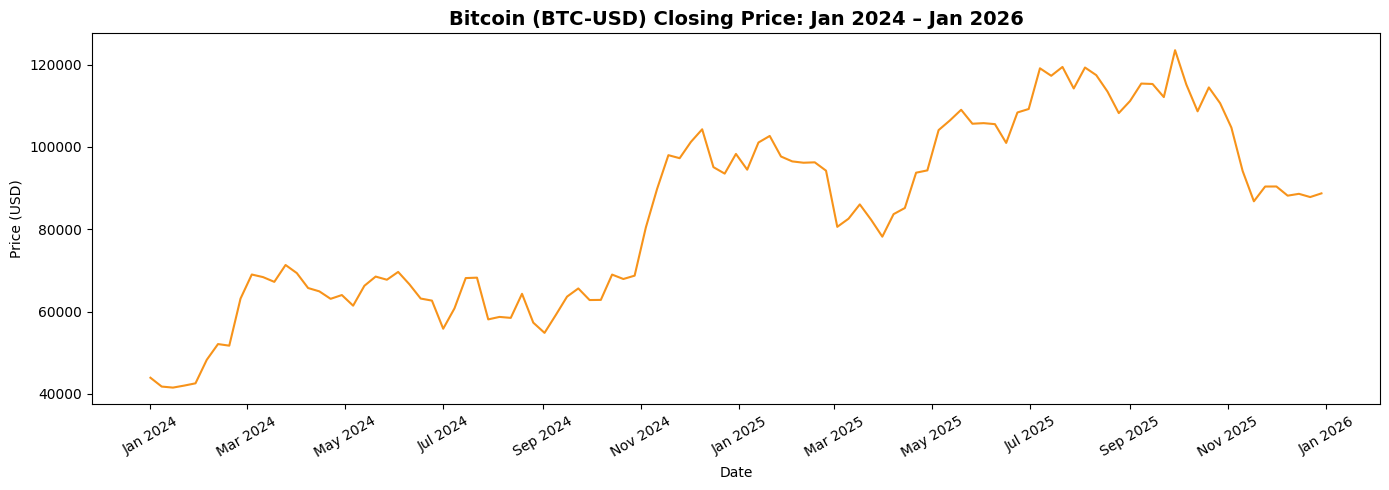

In [84]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_price_clean['date'], df_price_clean['close'], color='#F7931A', linewidth=1.5)
ax.set_title('Bitcoin (BTC-USD) Closing Price: Jan 2024 – Jan 2026', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig1_btc_price.png', dpi=150)
plt.show()

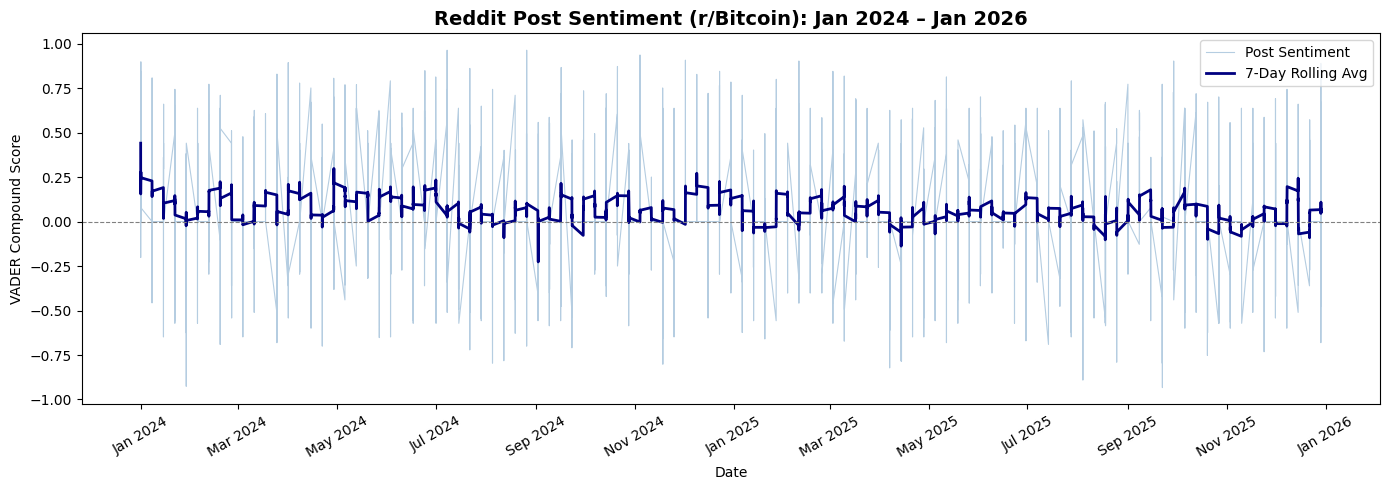

In [85]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_bitcoin_clean['timestamp'], df_bitcoin_clean['sentiment'],
        color='steelblue', linewidth=0.8, alpha=0.4, label='Post Sentiment')
rolling = df_bitcoin_clean.set_index('timestamp')['sentiment'].rolling('7D').mean()
ax.plot(rolling.index, rolling.values, color='navy', linewidth=2, label='7-Day Rolling Avg')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Reddit Post Sentiment (r/Bitcoin): Jan 2024 – Jan 2026', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('VADER Compound Score')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig2_sentiment_over_time.png', dpi=150)
plt.show()

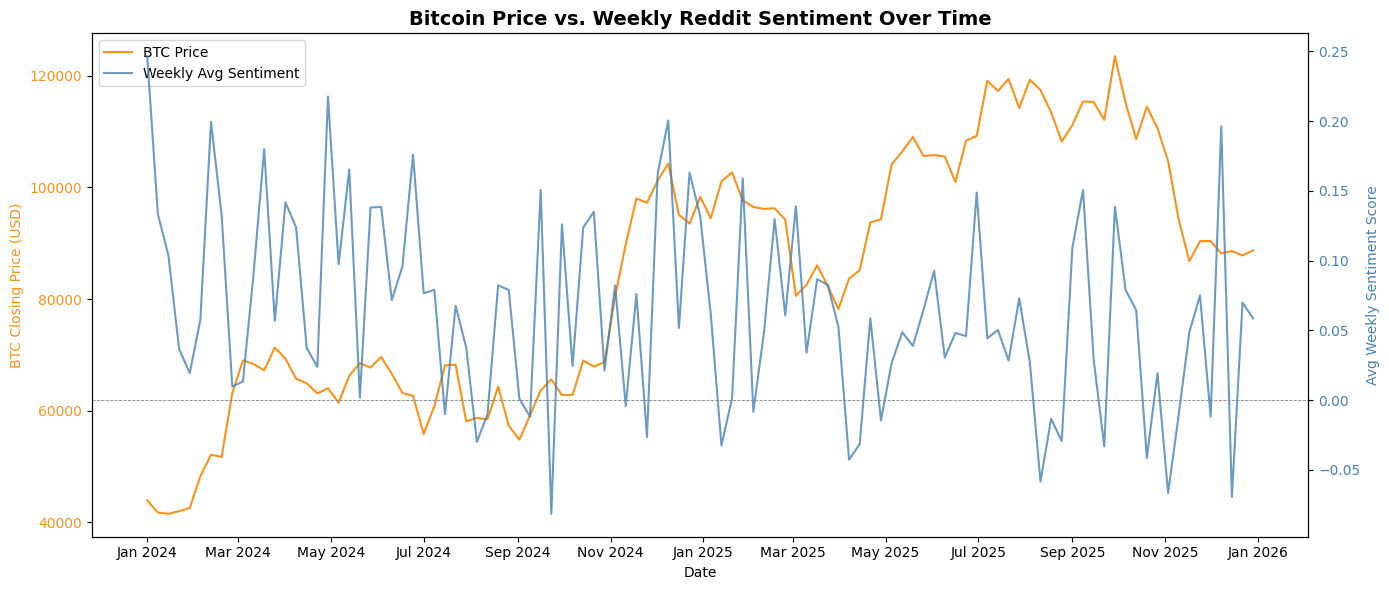

In [86]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(df_price_clean['date'], df_price_clean['close'], color='#F7931A', linewidth=1.5, label='BTC Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('BTC Closing Price (USD)', color='#F7931A')
ax1.tick_params(axis='y', labelcolor='#F7931A')

ax2 = ax1.twinx()
ax2.plot(df_merged['date'], df_merged['avg_sentiment'], color='steelblue', linewidth=1.5, alpha=0.8, label='Weekly Avg Sentiment')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.6)
ax2.set_ylabel('Avg Weekly Sentiment Score', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.set_title('Bitcoin Price vs. Weekly Reddit Sentiment Over Time', fontsize=14, fontweight='bold')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig3_price_vs_sentiment.png', dpi=150)
plt.show()

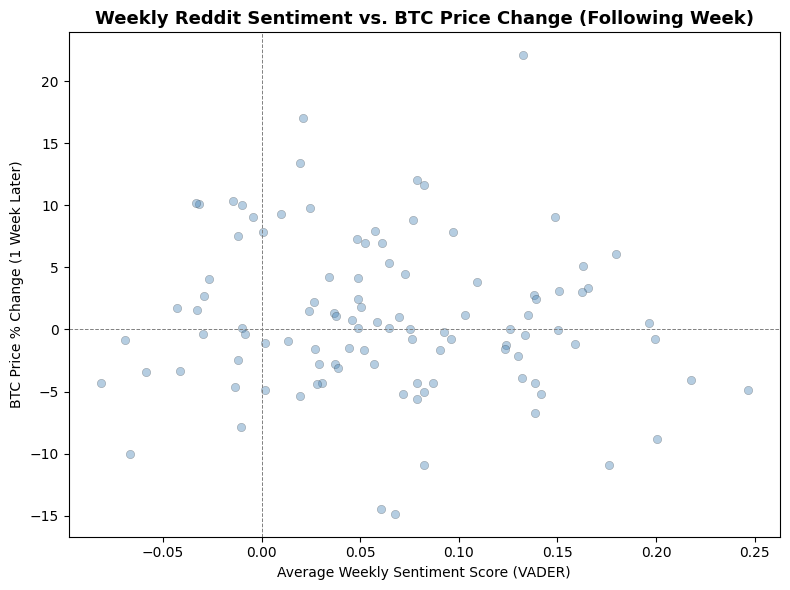

In [87]:
subset = df_merged[['avg_sentiment', 'price_pct_change']].copy()
subset['next_week_pct'] = subset['price_pct_change'].shift(-1)
subset = subset.dropna()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(subset['avg_sentiment'], subset['next_week_pct'],
           alpha=0.4, edgecolors='k', linewidths=0.3, color='steelblue')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)
ax.set_title('Weekly Reddit Sentiment vs. BTC Price Change (Following Week)', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Weekly Sentiment Score (VADER)')
ax.set_ylabel('BTC Price % Change (1 Week Later)')
plt.tight_layout()
plt.savefig('fig4_scatter_sentiment_vs_price.png', dpi=150)
plt.show()

##**Hypothesis Testing**

In [88]:
# RQ1 - does sentiment correlate with price change the following week?
df_merged['next_week_pct'] = df_merged['price_pct_change'].shift(-1)
rq1_data = df_merged[['avg_sentiment', 'next_week_pct']].dropna()

slope, intercept, r, p, se = linregress(rq1_data['avg_sentiment'], rq1_data['next_week_pct'])
print('RQ1: Sentiment vs. Next Week Price Change')
print(f'  r = {r:.4f}, p = {p:.4f}')

# RQ2 - do high upvote posts show a stronger relationship?
q75 = df_merged['avg_score'].quantile(0.75)

high_upvote = df_merged[df_merged['avg_score'] > q75][['avg_sentiment', 'next_week_pct']].dropna()
slope, intercept, r_high, p_high, se = linregress(high_upvote['avg_sentiment'], high_upvote['next_week_pct'])
print('\nRQ2: High vs. Low Upvote Posts')
print(f'  High upvote posts: r = {r_high:.4f}, p = {p_high:.4f}')

low_upvote = df_merged[df_merged['avg_score'] <= q75][['avg_sentiment', 'next_week_pct']].dropna()
slope, intercept, r_low, p_low, se = linregress(low_upvote['avg_sentiment'], low_upvote['next_week_pct'])
print(f'  Low upvote posts:  r = {r_low:.4f}, p = {p_low:.4f}')

RQ1: Sentiment vs. Next Week Price Change
  r = -0.0976, p = 0.3244

RQ2: High vs. Low Upvote Posts
  High upvote posts: r = -0.2167, p = 0.2982
  Low upvote posts:  r = -0.0367, p = 0.7481


##**Findings**

**RQ1**: The linear regression between average weekly sentiment and next-week Bitcoin price change showed basically no relationship (r = -0.0978, p = 0.3244). Looking at Figure 3, which overlays sentiment and price over time, there's no obvious pattern where sentiment spikes lead to price movement the following week. The scatter plot in Figure 4 confirms this — the points are pretty scattered with no clear trend in either direction. So based on this, weekly Reddit sentiment doesn't appear to be a reliable predictor of short-term Bitcoin price movement.

**RQ2:** High-upvote posts (score > 94) had a slightly stronger correlation with next-week price change (r = -0.2167, p = 0.2982) compared to low-upvote posts (r = -0.0367, p = 0.7491), but neither was statistically significant. The high-upvote group also only had 25 observations which makes it hard to draw any real conclusions. Interestingly both groups showed a negative direction, meaning more positive sentiment in high-engagement posts actually trended toward slight price drops the following week — though again not significantly. Figure 2 shows sentiment was generally positive throughout the period so this negative correlation is a bit counterintuitive.

**Overall:** Neither test produced significant results, which isn't too surprising given how noisy crypto markets are as shown in Figure 1. VADER also only runs on post titles, so a post like "Is Bitcoin dead?" would score close to neutral even though it's clearly negative. With more posts and maybe using comment text too the results might look different, but for this dataset sentiment alone doesn't predict price.